In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import neurokit2 as nk

In [2]:
meta_ecg_records = pd.read_csv('../data/datasets/ecg_records_metadata.csv') 
meta_ecg_records.head() 

,ECG_ID,Age,AHA_Code,Patient_ID,Sex,N,Date;
0,A00002,32,1,S00002,M,6000,2019-09-03;
1,A00003,63,1,S00003,M,6500,2020-07-16;
2,A00006,46,1,S00006,F,5000,2019-08-31;
3,A00008,32,1,S00008,M,5000,2019-10-02;
4,A00009,48,1,S00009,F,6000,2019-08-20;


<KeysViewHDF5 ['ECG_R_Peaks', 'Fractal_Dimension_P-R', 'Fractal_Dimension_PQRST', 'Fractal_Dimension_R-T', 'ecg']>
   ECG_ID  Age AHA_Code Patient_ID Sex     N        Date;
1  A00003   63        1     S00003   M  6500  2020-07-16;


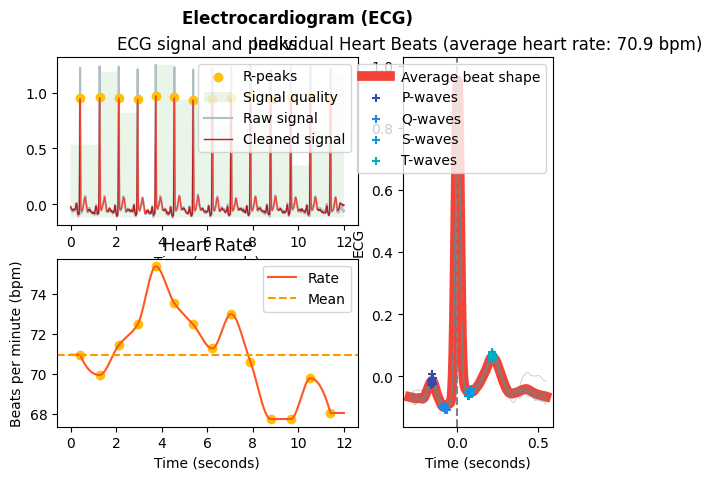

In [39]:

with h5py.File("../data/9694_ECG_records/A00002.h5", "r+") as f:
    print(f.keys())
    
    signal =  f['ecg'][1]
    
    signal_, info = nk.ecg_process(signal, sampling_rate=500)
    print(meta_ecg_records[meta_ecg_records['ECG_ID'] == 'A00003'])
    nk.ecg_plot(signal_, info)
    

<KeysViewHDF5 ['ECG_R_Peaks', 'Fractal_Dimension_P-R', 'Fractal_Dimension_PQRST', 'Fractal_Dimension_R-T', 'ecg']>
   ECG_ID  Age AHA_Code Patient_ID Sex     N        Date;
2  A00006   46        1     S00006   F  5000  2019-08-31;


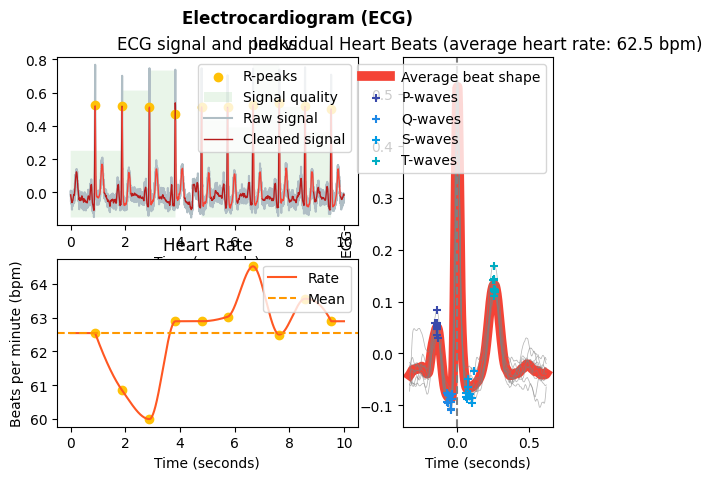

In [5]:

with h5py.File("../data/9694_ECG_records/A00006.h5", "r+") as f:
    print(f.keys())
    
    signal =  f['ecg'][1]
    
    signal_, info = nk.ecg_process(signal, sampling_rate=500)
    print(meta_ecg_records[meta_ecg_records['ECG_ID'] == 'A00006'])
    nk.ecg_plot(signal_, info)

### Features Extraction:
Rasgos a extraer:
- PR interval
- P-wave duration
- P-wave amplitude
- R-wave amplitude
- S-wave depth
- T-wave amplitude


In [33]:
# Dataset creation:

# Estructura del dataset de rasgos:
# PR_interval
# P_duration
# P_amplitude
# R_amplitude
# S_depth
# T_amplitude
    
    
features_df = pd.DataFrame(columns=['ECG_ID', 'PR_interval', 'P_duration', 'P_amplitude', 'R_amplitude', 'S_depth', 'T_amplitude'])
features_list = []


for id in meta_ecg_records['ECG_ID']:
    with h5py.File(f"../data/9694_ECG_records/{id}.h5", "r+") as f:
        ecg =  f['ecg'][1]
        signal, info = nk.ecg_process(ecg, sampling_rate=500)
        
        ecg_clean = signal["ECG_Clean"].values

        r_peaks   = info['ECG_R_Peaks']
        p_peaks   = info['ECG_P_Peaks']
        p_onsets  = info['ECG_P_Onsets']
        p_offsets = info['ECG_P_Offsets']
        s_peaks   = info['ECG_S_Peaks']
        t_peaks   = info['ECG_T_Peaks']
        sampling_rate = info['sampling_rate']
        
        n_beats = len(r_peaks)
        
        features = {
            'PR_interval': [],
            'P_duration': [],
            'P_amplitude': [],
            'R_amplitude': [],
            'S_depth': [],
            'T_amplitude': []
        }
        
        for i in range(n_beats):
            # PR_interval: P_Onset -> R_Peak (ms)
            if not np.isnan(p_onsets[i]) and not np.isnan(r_peaks[i]):
                pr = (r_peaks[i] - p_onsets[i]) / sampling_rate * 1000
            else:
                pr = np.nan
            features['PR_interval'].append(pr)
            
            # P_duration: P_Onset -> P_Offset (ms)
            if not np.isnan(p_onsets[i]) and not np.isnan(p_offsets[i]):
                pdur = (p_offsets[i] - p_onsets[i]) / sampling_rate * 1000
            else:
                pdur = np.nan
            features['P_duration'].append(pdur)
            
            # Amplitudes (mV) leídas de la señal limpia
            features['P_amplitude'].append(ecg_clean[int(p_peaks[i])]   if not np.isnan(p_peaks[i])   else np.nan)
            features['R_amplitude'].append(ecg_clean[int(r_peaks[i])]   if not np.isnan(r_peaks[i])   else np.nan)
            features['S_depth'].append(    ecg_clean[int(s_peaks[i])]   if not np.isnan(s_peaks[i])   else np.nan)
            features['T_amplitude'].append(ecg_clean[int(t_peaks[i])]   if not np.isnan(t_peaks[i])   else np.nan)

        mean_pr_interval = np.nanmean(features['PR_interval'])
        mean_p_duration = np.nanmean(features['P_duration'])
        mean_p_amplitude = np.nanmean(features['P_amplitude'])
        mean_r_amplitude = np.nanmean(features['R_amplitude'])
        mean_s_depth = np.nanmean(features['S_depth'])
        mean_t_amplitude = np.nanmean(features['T_amplitude'])

        features_to_df = {
            'ECG_ID': id,
            'PR_interval': mean_pr_interval,
            'P_duration': mean_p_duration,
            'P_amplitude': mean_p_amplitude,
            'R_amplitude': mean_r_amplitude,
            'S_depth': mean_s_depth,
            'T_amplitude': mean_t_amplitude
        }
        

        features_list.append(features_to_df)
        
        print(f"Processed {id}: {features_to_df}")
        


features_df = pd.DataFrame(features_list)
features_df.set_index('ECG_ID', inplace=True)
features_df.head()
        


Processed A00002: {'ECG_ID': 'A00002', 'PR_interval': np.float64(210.92307692307693), 'P_duration': np.float64(106.15384615384616), 'P_amplitude': np.float64(-0.014168052669096376), 'R_amplitude': np.float64(0.952738858704804), 'S_depth': np.float64(-0.05387311690779671), 'T_amplitude': np.float64(0.06309815109308865)}
Processed A00003: {'ECG_ID': 'A00003', 'PR_interval': np.float64(207.125), 'P_duration': np.float64(106.75), 'P_amplitude': np.float64(0.1537672397523745), 'R_amplitude': np.float64(0.42257501364770467), 'S_depth': np.float64(-0.09908513689349555), 'T_amplitude': np.float64(0.06425364849055896)}
Processed A00006: {'ECG_ID': 'A00006', 'PR_interval': np.float64(208.2), 'P_duration': np.float64(122.6), 'P_amplitude': np.float64(0.051325339497613774), 'R_amplitude': np.float64(0.5138005464746798), 'S_depth': np.float64(-0.07326519687951706), 'T_amplitude': np.float64(0.1329755023263059)}
Processed A00008: {'ECG_ID': 'A00008', 'PR_interval': np.float64(190.2), 'P_duration': n

,PR_interval,P_duration,P_amplitude,R_amplitude,S_depth,T_amplitude
ECG_ID,,,,,,
A00002,210.923077,106.153846,-0.014168,0.952739,-0.053873,0.063098
A00003,207.125000,106.750000,0.153767,0.422575,-0.099085,0.064254
A00006,208.200000,122.600000,0.051325,0.513801,-0.073265,0.132976
A00008,190.200000,109.600000,0.055782,0.712922,-0.091710,0.193799
A00009,160.666667,100.333333,0.068612,0.492980,-0.134314,0.145174


In [35]:
# Save dataset
features_df.to_csv("../data/datasets/9694_ECG_features.csv")